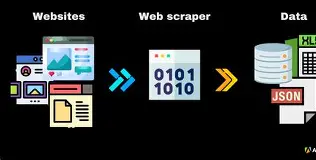

In [ ]:
import requests
from bs4 import BeautifulSoup
url="https://subslikescript.com/movie/Titanic-120338"
result=requests.get(url)
content=result.text
soup=BeautifulSoup(content , "html.parser")
print(soup.prettify())

In [15]:
soup.find("h1").text

'Titanic (1997) - full transcript'

In [18]:
soup.find("h1").get_text()

'Titanic (1997) - full transcript'

In [25]:
print(len(soup.find_all("a" ,href=True)))
soup.find_all("a" ,href=True)

8


[<a href="/" title="Subs like Script - all Movies and TV Shows Transcripts">
 <span>SUBSLIKESCRIPT</span>
 </a>,
 <a href="/movies" target="_self" title="All movies transcripts">Movies</a>,
 <a href="/series" target="_self" title="All Tv Shows transcripts">TV Shows</a>,
 <a href="/">Home</a>,
 <a href="/movies">Movies</a>,
 <a href="/movies">All movie scripts</a>,
 <a href="/series">All Tv-Show scripts</a>,
 <a href="/dmca">DMCA</a>]

In [41]:
movie=soup.find("article",class_="main-article")
movie.find("h1").text

'Titanic (1997) - full transcript'

In [50]:
script=movie.find("div",class_="full-script").get_text()

In [69]:
title=soup.find("h1").text.strip().split()[0]

In [71]:
with open(f"{title}.txt", "w", encoding="utf-8") as file:
    file.write(script)

Data successfully written to


# Titanic Done 

# Now Go for all movies 

In [98]:
import requests
from bs4 import BeautifulSoup
url="https://subslikescript.com/movies"
result=requests.get(url)
content=result.text
soup=BeautifulSoup(content , "html.parser")

In [101]:
print(len(soup.find_all("a" ,href=True)))
box=soup.find("article" ,class_="main-article")

86


In [103]:
link=box.find_all("a",href=True)

In [119]:
links=[]
for i in link:
    links.append("https://subslikescript.com/"+i["href"])

In [125]:
for i in links:
    result = requests.get(i)
    content = result.text
    soup = BeautifulSoup(content, "html.parser")
    box = soup.find("article", class_="main-article")
    script = box.find("div", class_="full-script").text
    title = box.find("h1").text
    if "-" in title:
        title = title.split("-")[0]
    
    try:
        with open(f"{title}.txt", "w", encoding="utf-8") as file:
            file.write(script)
    except Exception as e:
        print(f"Error saving {title}: {e}")
